# Notebook 01.3 — Aquisição e Caracterização da Oferta (UBS + capacidade CNES)

**Projeto:** Acessibilidade Geográfica às UBS de Teresina — roteiro computacional AE2SFCA
**Programa:** MAPEPROF — Mestrado Profissional em Planejamento Urbano e Regional / IFPI
**Autor:** Felipe Ramos Dantas
**Orientador:** Prof. Dr. Antonio Joaquim da Silva | **Coorientador:** Prof. Dr. Reurysson Chagas de Sousa Morais
**Repositório:** https://github.com/felipedantas-pi/ae2sfca-ubs
**Última atualização:** 2026-06-15

---
## Objetivo
Adquirir a camada de **oferta de saúde** do modelo AE2SFCA — as UBS da zona urbana de
Teresina — e quantificar sua **capacidade** (`S_j`) a partir da Base de Dados CNES
(DataSUS), de forma **automatizada e reprodutível**. Caracteriza-se a oferta por análise
estatística e cartográfica.

## Entrada
| Arquivo | Origem |
|---|---|
| `externos/pmt/ubs_zonaUrbana.geojson` | SEMPLAN (localização das UBS, com código CNES) |
| Base de Dados CNES `BASE_DE_DADOS_CNES_AAAAMM.ZIP` | DataSUS (download automatizado) |

## Saída
| Arquivo | Consumido por |
|---|---|
| `intermediarios/03_ubs/teresina_ubs_capacidade_utm.parquet` | NB 05 (oferta `S_j`) |

## Pré-requisitos
- Conexão de internet no primeiro download (~700 MB, em cache depois).
- NB 01.1 executado (limites territoriais para os mapas).
---

In [15]:
# ── 1. IMPORTAÇÕES E CONFIGURAÇÃO ───────────────────────────────────────────
import warnings, urllib.request, shutil, zipfile
import numpy as np, pandas as pd, geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

from mapeprof.config import (EXT_PMT, EXT_CNES, EXT_IBGE, INT_MALHA, INT_UBS,
                             FIGURAS, TABELAS, CRS_METRICO, criar_diretorios)
from mapeprof.viz import (
    aplicar_estilo, barra_escala, seta_norte, 
    moldura_mapa, formatar_eixos_mapa, ajustar_zoom_camada
)
aplicar_estilo()

warnings.filterwarnings("ignore")
criar_diretorios()
FIGURAS_NB = FIGURAS / "nb013"; FIGURAS_NB.mkdir(parents=True, exist_ok=True)
TABELAS_NB = TABELAS / "nb013"; TABELAS_NB.mkdir(parents=True, exist_ok=True)
print("✅ Setup concluído.")

✅ Setup concluído.


## 2. Aquisição automatizada da Base CNES (DataSUS)

A capacidade das UBS é obtida da Base de Dados CNES, baixada **diretamente do servidor do
DataSUS** pela competência (AAAAMM), fixada para reprodutibilidade. A função é
*idempotente*: só baixa se o arquivo ainda não existir localmente.

In [2]:
# ── 2. DOWNLOAD AUTOMATIZADO DA BASE CNES ───────────────────────────────────
def baixar_base_cnes(competencia: str, destino=EXT_CNES):
    """Baixa a Base de Dados CNES do DataSUS para a competência AAAAMM (idempotente)."""
    arquivo = destino / f"BASE_DE_DADOS_CNES_{competencia}.ZIP"
    if arquivo.exists():
        print(f"✅ Base CNES {competencia} já presente: {arquivo.name}")
        return arquivo
    url = (f"https://cnes.datasus.gov.br/EstatisticasServlet?"
           f"path=BASE_DE_DADOS_CNES_{competencia}.ZIP")
    destino.mkdir(parents=True, exist_ok=True)
    req = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})
    print(f"⬇️ Baixando CNES {competencia} (~700 MB, pode levar minutos)...")
    with urllib.request.urlopen(req, timeout=300) as resp, open(arquivo, "wb") as f:
        shutil.copyfileobj(resp, f)
    print(f"✅ Salvo: {arquivo}")
    return arquivo

COMPETENCIA_CNES = "202604"   # fixa a competência (reprodutibilidade)
zip_cnes = baixar_base_cnes(COMPETENCIA_CNES)

✅ Base CNES 202604 já presente: BASE_DE_DADOS_CNES_202604.ZIP


## 3. Capacidade da oferta: equipes de Atenção Primária

A capacidade de cada UBS (`S_j`) é definida como o **número de equipes de Atenção Primária
ativas** — equipes de Saúde da Família (eSF, `TP_EQUIPE`=71) e equipes de Atenção Primária
(eAP, `TP_EQUIPE`=70) —, unidade de capacidade da APS segundo a PNAB. O código CNES (7
dígitos) corresponde aos últimos 7 dígitos de `CO_UNIDADE` na tabela de equipes.

In [11]:
# ── 3. CAPACIDADE (S_j) E JUNÇÃO COM AS UBS ─────────────────────────────────
COD_MUNICIPIO_TERESINA = "221100"
TIPOS_EQUIPE_APS = {"70", "71"}   # 70=eAP | 71=eSF

with zipfile.ZipFile(zip_cnes) as z:
    equipes = pd.read_csv(z.open(f"tbEquipe{COMPETENCIA_CNES}.csv"),
                          sep=";", encoding="latin-1", dtype=str)

ativas = equipes[(equipes["CO_MUNICIPIO"] == COD_MUNICIPIO_TERESINA)
                 & (equipes["DT_DESATIVACAO"].isna())
                 & (equipes["TP_EQUIPE"].isin(TIPOS_EQUIPE_APS))].copy()
ativas["cnes"] = ativas["CO_UNIDADE"].str[-7:]

capacidade = ativas.groupby("cnes").size().rename("capacidade_equipes")
n_esf = ativas[ativas["TP_EQUIPE"] == "71"].groupby("cnes").size()
n_eap = ativas[ativas["TP_EQUIPE"] == "70"].groupby("cnes").size()

# UBS vêm da camada baixada manualmente da Prefeitura (93 unidades, urbanas + rurais)
ubs = gpd.read_file(EXT_PMT / "ubs.geojson").to_crs(CRS_METRICO)
ubs.columns = ubs.columns.str.lower()
ubs["capacidade_equipes"] = ubs["cnes"].astype(str).map(capacidade).fillna(0).astype(int)
ubs["n_esf"] = ubs["cnes"].astype(str).map(n_esf).fillna(0).astype(int)
ubs["n_eap"] = ubs["cnes"].astype(str).map(n_eap).fillna(0).astype(int)

# ── Filtro espacial da OFERTA ───────────────────────────────────────────────
# Mantêm-se as UBS dentro do ENVELOPE DE CÁLCULO (zona urbana + buffer de 5 km),
# e NÃO apenas as estritamente dentro da zona urbana. Motivo: uma UBS de borda,
# fora do perímetro urbano mas dentro dos 5 km, tem captação que alcança a franja
# da cidade e atende população urbana; excluí-la subestimaria o acesso na borda
# (efeito de borda). As UBS rurais distantes (fora do buffer) saem da análise.
area_estudo  = gpd.read_parquet(EXT_IBGE / "teresina_zonaUrbana_buffer5kClip_utm.parquet").to_crs(CRS_METRICO).geometry.union_all()
zona_urbana  = gpd.read_parquet(EXT_IBGE / "teresina_zonaUrbana_utm.parquet").to_crs(CRS_METRICO).geometry.union_all()

ubs["na_zona_urbana"] = ubs.geometry.within(zona_urbana)   # rótulo p/ mapas e relato
na_area_estudo        = ubs.geometry.within(area_estudo)    # critério de inclusão (oferta)

n_antes = len(ubs)

saida_todos = INT_UBS / "teresina_ubs_capacidade.parquet"
ubs.to_parquet(saida_todos)
print(f"💾 Salvo: {saida_todos}\n\n")

ubs = ubs[na_area_estudo].copy()                            # mantém urbanas + de borda

saida_zu5km = INT_UBS / "teresina_zonaUrbana_buffer5km_ubs_capacidade.parquet"
ubs.to_parquet(saida_zu5km)

print(f"💾 UBS na área de estudo (ZU+5km): {len(ubs)} de {n_antes} | rurais descartadas: {n_antes - len(ubs)}")
print(f"   estritamente na zona urbana: {int(ubs['na_zona_urbana'].sum())} | de borda (no buffer): {int((~ubs['na_zona_urbana']).sum())}")
print(f"   total de equipes de APS: {ubs['capacidade_equipes'].sum()} | UBS sem equipe: {int((ubs['capacidade_equipes']==0).sum())}")
print(f"💾 Salvo: {saida_zu5km}")

💾 Salvo: C:\Users\felipe\workspace_pcksa\ae2sfca_ubs\dados\intermediarios\03_ubs\teresina_ubs_capacidade.parquet


💾 UBS na área de estudo (ZU+5km): 81 de 93 | rurais descartadas: 12
   estritamente na zona urbana: 75 | de borda (no buffer): 6
   total de equipes de APS: 474 | UBS sem equipe: 1
💾 Salvo: C:\Users\felipe\workspace_pcksa\ae2sfca_ubs\dados\intermediarios\03_ubs\teresina_zonaUrbana_buffer5km_ubs_capacidade.parquet


## 4. Análise exploratória da oferta

Caracterização estatística e cartográfica da capacidade instalada, base para a
interpretação dos resultados de acessibilidade (NB 05).

In [13]:
# ── 4.1 SÍNTESE ESTATÍSTICA DA OFERTA (robusta, salva em tabela) ─────────────
# População urbana (demanda) para as razões de cobertura
_set = gpd.read_parquet(INT_MALHA / "teresina_setoresCensitarios_DadosCompletos.parquet")
pop_urbana = pd.to_numeric(_set["populacao"], errors="coerce")
pop_urbana = float(pop_urbana[pop_urbana > 0].sum())

cap = ubs["capacidade_equipes"]
indicadores = {
    "UBS na área de estudo (nº)":        len(ubs),
    "UBS na zona urbana estrita (nº)":   int(ubs["na_zona_urbana"].sum()),
    "UBS de borda, no buffer (nº)":      int((~ubs["na_zona_urbana"]).sum()),
    "UBS sem equipe registrada (nº)":    int((cap == 0).sum()),
    "Equipes de APS (total)":            int(cap.sum()),
    "  eSF, tipo 71 (nº)":               int(ubs["n_esf"].sum()),
    "  eAP, tipo 70 (nº)":               int(ubs["n_eap"].sum()),
    "Equipes por UBS — média":           round(cap.mean(), 2),
    "Equipes por UBS — mediana":         round(cap.median(), 2),
    "Equipes por UBS — desvio-padrão":   round(cap.std(), 2),
    "Equipes por UBS — CV (%)":          round(cap.std() / cap.mean() * 100, 1),
    "Equipes por UBS — mínimo":          int(cap.min()),
    "Equipes por UBS — Q1":              round(cap.quantile(.25), 1),
    "Equipes por UBS — Q3":              round(cap.quantile(.75), 1),
    "Equipes por UBS — máximo":          int(cap.max()),
    "População urbana (hab.)":           int(pop_urbana),
    "Equipes por 10 mil habitantes":     round(cap.sum() / pop_urbana * 10000, 2),
    "Habitantes por equipe de APS":      int(pop_urbana / cap.sum()),
}
tab_sintese = pd.Series(indicadores, name="valor").to_frame()
tab_sintese.to_csv(TABELAS_NB / "nb013_sintese_oferta.csv", sep=";", encoding="utf-8-sig")

# Oferta por regional administrativa
tab_regional = (ubs.groupby("regional")
                .agg(n_ubs=("capacidade_equipes", "size"),
                     equipes=("capacidade_equipes", "sum"),
                     media_equipes=("capacidade_equipes", "mean"),
                     eSF=("n_esf", "sum"), eAP=("n_eap", "sum"))
                .sort_values("equipes", ascending=False).round(1))
tab_regional["% equipes"] = (tab_regional["equipes"] / tab_regional["equipes"].sum() * 100).round(1)
tab_regional.to_csv(TABELAS_NB / "nb013_oferta_por_regional.csv", sep=";", encoding="utf-8-sig")

print(tab_sintese.to_string()); print("\n", tab_regional.to_string())
print(f"\n💾 Tabelas salvas em {TABELAS_NB}")

                                     valor
UBS na área de estudo (nº)           81.00
UBS na zona urbana estrita (nº)      75.00
UBS de borda, no buffer (nº)          6.00
UBS sem equipe registrada (nº)        1.00
Equipes de APS (total)              474.00
  eSF, tipo 71 (nº)                 226.00
  eAP, tipo 70 (nº)                 248.00
Equipes por UBS — média               5.85
Equipes por UBS — mediana             6.00
Equipes por UBS — desvio-padrão       2.67
Equipes por UBS — CV (%)             45.50
Equipes por UBS — mínimo              0.00
Equipes por UBS — Q1                  4.00
Equipes por UBS — Q3                  8.00
Equipes por UBS — máximo             12.00
População urbana (hab.)          807660.00
Equipes por 10 mil habitantes         5.87
Habitantes por equipe de APS       1703.00

           n_ubs  equipes  media_equipes  eSF  eAP  % equipes
regional                                                    
SUL          28      156            5.6   73   83       32.

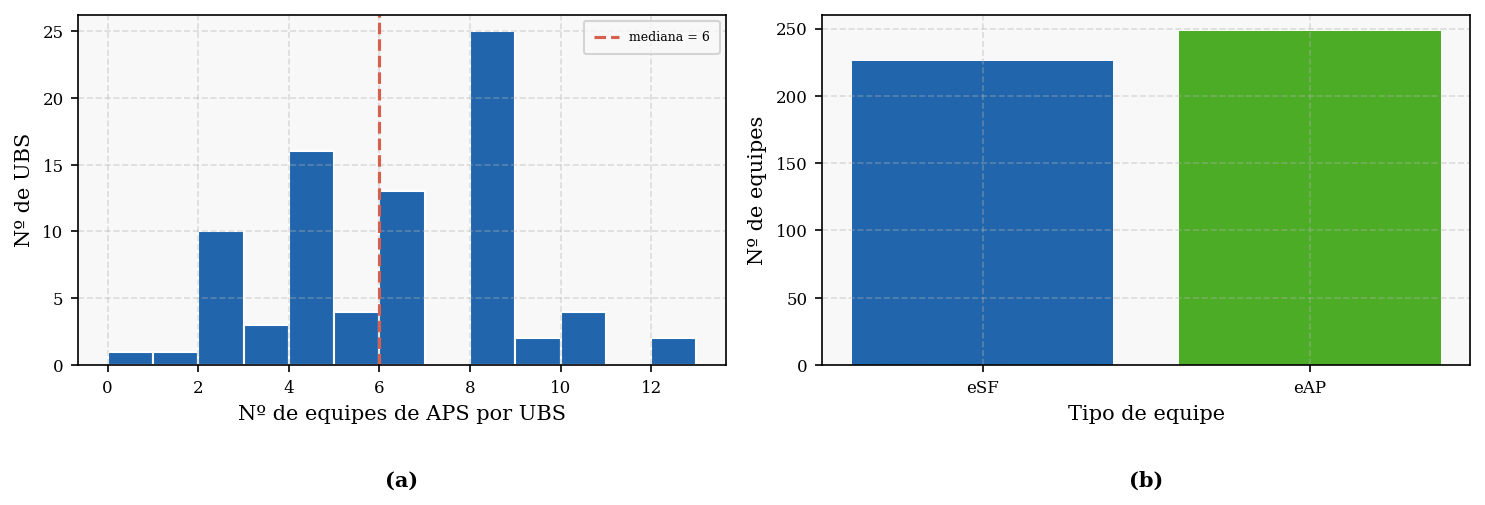

In [29]:
# ── Fig. 01 — Distribuição da capacidade e composição das equipes ───────────
fig, (a1, a2) = plt.subplots(1, 2, figsize=(10, 3.6))

a1.hist(ubs["capacidade_equipes"], bins=range(0, 14), color="#2166AC", edgecolor="white")
a1.axvline(ubs["capacidade_equipes"].median(), ls="--", color="#D6604D",
           label=f"mediana = {ubs['capacidade_equipes'].median():.0f}")
a1.set_xlabel("Nº de equipes de APS por UBS"); a1.set_ylabel("Nº de UBS"); a1.legend()

a2.bar(["eSF", "eAP"], [ubs["n_esf"].sum(), ubs["n_eap"].sum()],
       color=["#2166AC", "#4DAC26"])
a2.set_xlabel("Tipo de equipe"); a2.set_ylabel("Nº de equipes")

# Identificadores de painel, centralizados abaixo de cada gráfico
a1.text(0.5, -0.30, "(a)", transform=a1.transAxes, ha="center", va="top", fontweight="bold")
a2.text(0.5, -0.30, "(b)", transform=a2.transAxes, ha="center", va="top", fontweight="bold")

plt.tight_layout()
plt.savefig(FIGURAS_NB / "nb013_fig01_capacidade_distribuicao.png", dpi=300, bbox_inches="tight")
plt.show()

## 4.2 Distribuição espacial da oferta

Mapas que espacializam a capacidade (símbolos proporcionais), categorizam-na
qualitativamente (classes de capacidade) e a relacionam à divisão administrativa
(regionais de saúde).

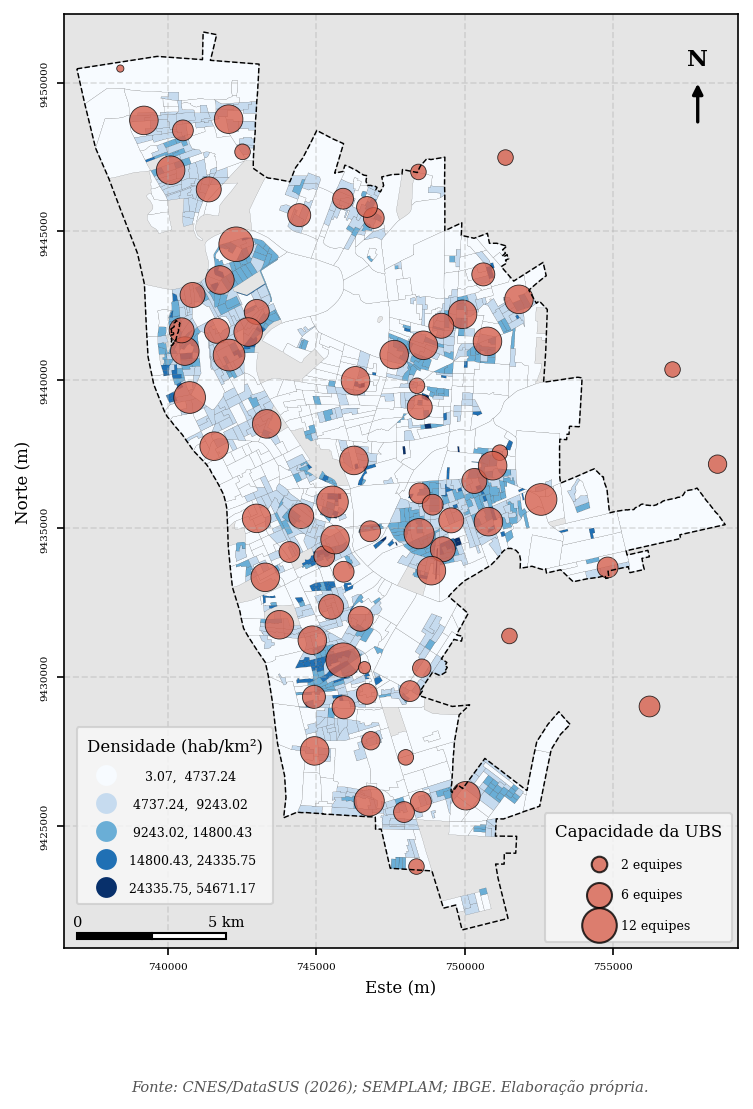

In [22]:
# ── Fig. 02 — OFERTA (UBS) SOBRE A DEMANDA (densidade populacional) ──────────
setores = gpd.read_parquet(INT_MALHA / "teresina_setoresCensitarios_DadosCompletos.parquet").to_crs(CRS_METRICO)

setores["populacao"] = pd.to_numeric(setores["populacao"], errors="coerce")
setores["dens_hab_km2"] = setores["populacao"] / (setores.geometry.area / 1e6)   # densidade = demanda
zona_urbana = gpd.read_parquet(EXT_IBGE / "teresina_zonaUrbana_utm.parquet").to_crs(CRS_METRICO)

# Ajuste para folha A5 Retrato (padrão unificado do projeto)
fig, ax = plt.subplots(figsize=(5.8, 8.3))

# ──> FUNDO CINZA CLARO: Destaca os setores de densidade nula/baixa
ax.set_facecolor("#E5E5E5")

# 1. PLOTAGEM DO FUNDO (Demanda)
# fundo: demanda (densidade populacional, quintis)
setores.plot(ax=ax, column="dens_hab_km2", scheme="NaturalBreaks", k=5, cmap="Blues",
             legend=True,
             legend_kwds={
                "title": "Densidade (hab/km²)",
                "loc": "lower left",
                "fmt": "{:.2f}",
                "bbox_to_anchor": (0.01, 0.04),  # <-- Empurra a legenda 8% para cima, fugindo da escala
             },
             edgecolor="black", linewidth=0.05)

# ──> O TRUQUE DA LEGENDA: Salvar a primeira legenda na memória antes de continuar
legenda_demanda = ax.get_legend()

# 2. PLOTAGEM DA SOBREPOSIÇÃO (Oferta)
# sobreposição: oferta (UBS, símbolo proporcional à capacidade)
ubs.plot(ax=ax, markersize=ubs["capacidade_equipes"] * 22 + 12,
         color="#D6604D", alpha=0.8, edgecolor="black", linewidth=0.4)
zona_urbana.boundary.plot(ax=ax, color="black", ls="--", lw=0.7)

# 3. CRIAÇÃO DA SEGUNDA LEGENDA (Círculos Proporcionais)
# legenda de tamanho (mesma convenção de área do markersize)
for n in (2, 6, 12):
    ax.scatter([], [], s=n * 22 + 12, color="#D6604D", alpha=0.8, edgecolor="black", label=f"{n} equipes")

# Este comando sobrescreve o espaço de legenda primário do Eixo
ax.legend(title="Capacidade da UBS", loc="lower right", labelspacing=1.4)

# ──> O TRUQUE DA LEGENDA: Adicionar a primeira legenda de volta ao mapa
ax.add_artist(legenda_demanda)



# 4. FORMATAÇÃO CARTOGRÁFICA (via viz.py)
formatar_eixos_mapa(ax, fontsize=8)                  
ajustar_zoom_camada(ax, setores, margem=0.02)

moldura_mapa(ax, "", "CNES/DataSUS (2026); SEMPLAM; IBGE. Elaboração própria.")
barra_escala(ax); seta_norte(ax)

fig.savefig(FIGURAS_NB / "nb013_fig02_oferta_demanda.png", dpi=300, bbox_inches="tight")
plt.show()

ESF: 240 áreas | cobertura: 87.2% da área | 97.3% da população | 22,161 hab. sem cobertura


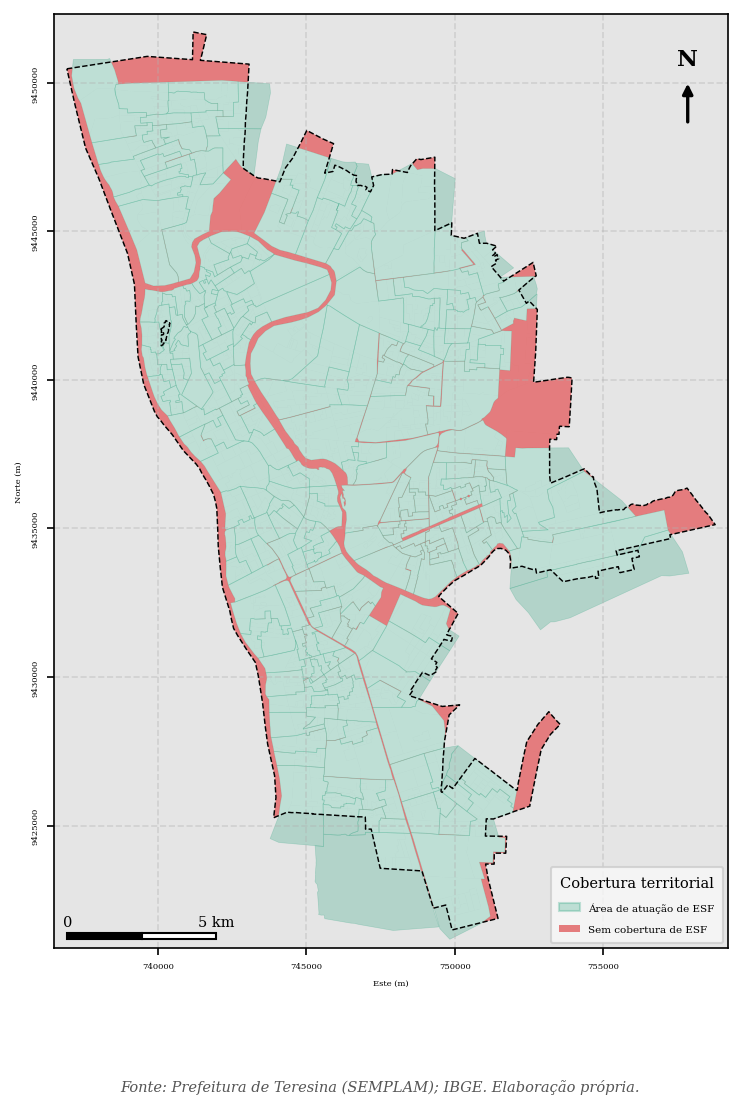

In [27]:
# ── Fig. 03 — ÁREAS DE ATUAÇÃO DAS ESF E LACUNAS DE COBERTURA ────────────────
from shapely.ops import unary_union
from matplotlib.patches import Patch

esf = gpd.read_file(EXT_PMT / "area_das_esf.geojson").to_crs(CRS_METRICO)
esf["geometry"] = esf.geometry.buffer(0)        # corrige polígonos inválidos do KML
zu_geom = zona_urbana.geometry.iloc[0]

cobertura = unary_union(esf.geometry)                                  # união das áreas de atuação
lacuna = gpd.GeoSeries([zu_geom.difference(cobertura)], crs=CRS_METRICO)  # zona urbana NÃO coberta

# Síntese de cobertura (números para o texto)
frac = (setores.geometry.intersection(cobertura).area / setores.geometry.area).clip(0, 1)
pop_cob, pop_tot = (setores["populacao"] * frac).sum(), setores["populacao"].sum()
print(f"ESF: {len(esf)} áreas | cobertura: {cobertura.intersection(zu_geom).area/zu_geom.area*100:.1f}% da área | "
      f"{pop_cob/pop_tot*100:.1f}% da população | {pop_tot - pop_cob:,.0f} hab. sem cobertura")

# Mapa (padrão cartográfico A5)
fig, ax = plt.subplots(figsize=(5.8, 8.3)); ax.set_facecolor("#E5E5E5")
setores.plot(ax=ax, color="#F5F5F5", edgecolor="white", linewidth=0.05)                  # contexto: setores
esf.plot(ax=ax, facecolor="#1B9E77", alpha=0.25, edgecolor="#1B9E77", linewidth=0.3)     # áreas de atuação
lacuna.plot(ax=ax, facecolor="#D7191C", alpha=0.55, edgecolor="none")                    # lacunas
zona_urbana.boundary.plot(ax=ax, color="black", ls="--", lw=0.7)

ax.legend(handles=[Patch(facecolor="#1B9E77", alpha=0.25, edgecolor="#1B9E77", label="Área de atuação de ESF"),
                   Patch(facecolor="#D7191C", alpha=0.55, label="Sem cobertura de ESF")],
          loc="lower right", title="Cobertura territorial", fontsize=5, title_fontsize=7)

ajustar_zoom_camada(ax, zona_urbana, margem=0.02)
moldura_mapa(ax, "", "Prefeitura de Teresina (SEMPLAM); IBGE. Elaboração própria.")
formatar_eixos_mapa(ax, fontsize=4); barra_escala(ax); seta_norte(ax)
fig.savefig(FIGURAS_NB / "nb013_fig03_areas_esf.png", dpi=300, bbox_inches="tight")
plt.show()

---
## Próximos passos
A camada `teresina_ubs_capacidade_utm.parquet` fornece a oferta `S_j` (nº de equipes de
APS) ao **NB 05**, onde substitui a oferta provisória unitária no cálculo do AE2SFCA.